In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
data = {
    "text": [
        "Government announces new scholarship program for students",
        "Scientists discover new species in the Amazon rainforest",
        "NASA announces successful space research mission",
        "New public transportation rules announced by authorities",
        "Researchers publish study on climate change",
        "University announces new artificial intelligence course",

        "Celebrity discovers secret method to live forever",
        "Government will give every citizen one million dollars tomorrow",
        "Scientists confirm humans can survive without sleep",
        "Drinking one glass of water makes you lose ten kilograms instantly",
        "Aliens officially contacted Earth according to anonymous sources",
        "Miracle medicine can cure every disease in one day"
    ],

    "label": [
        "REAL",
        "REAL",
        "REAL",
        "REAL",
        "REAL",
        "REAL",

        "FAKE",
        "FAKE",
        "FAKE",
        "FAKE",
        "FAKE",
        "FAKE"
    ]
}

df = pd.DataFrame(data)

df

,text,label
0,Government announces new scholarship program f...,REAL
1,Scientists discover new species in the Amazon ...,REAL
2,NASA announces successful space research mission,REAL
3,New public transportation rules announced by a...,REAL
4,Researchers publish study on climate change,REAL
5,University announces new artificial intelligen...,REAL
6,Celebrity discovers secret method to live forever,FAKE
7,Government will give every citizen one million...,FAKE
8,Scientists confirm humans can survive without ...,FAKE
9,Drinking one glass of water makes you lose ten...,FAKE


In [5]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["label"].value_counts())

Dataset Shape: (12, 2)

Missing Values:
text     0
label    0
dtype: int64

Class Distribution:
label
REAL    6
FAKE    6
Name: count, dtype: int64


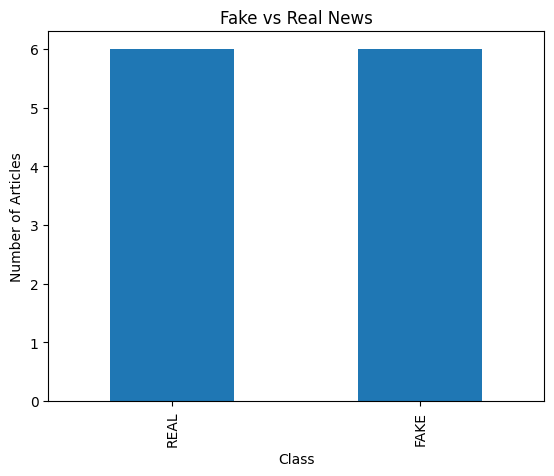

In [6]:
df["label"].value_counts().plot(kind="bar")

plt.title("Fake vs Real News")
plt.xlabel("Class")
plt.ylabel("Number of Articles")

plt.show()

In [7]:
X = df["text"]
y = df["label"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 9
Testing samples: 3


In [9]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            max_features=5000
        )
    ),

    (
        "classifier",
        LogisticRegression(max_iter=1000)
    )
])

In [10]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [11]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.3333333333333333


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        FAKE       0.00      0.00      0.00         2
        REAL       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


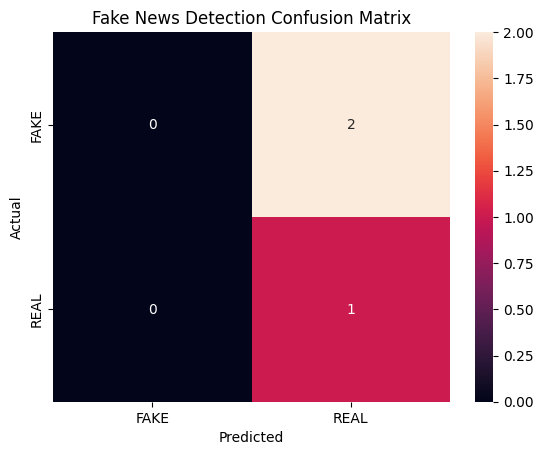

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["FAKE", "REAL"],
    yticklabels=["FAKE", "REAL"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fake News Detection Confusion Matrix")

plt.show()

In [14]:
news = """
Scientists announce a new research project to study climate change.
"""

prediction = model.predict([news])[0]

probability = model.predict_proba([news])[0].max()

print("Prediction:", prediction)
print("Confidence:", round(probability * 100, 2), "%")

Prediction: REAL
Confidence: 60.66 %


In [15]:
news = """
A miracle drink allows every person to become immortal within one day.
"""

prediction = model.predict([news])[0]

probability = model.predict_proba([news])[0].max()

print("Prediction:", prediction)
print("Confidence:", round(probability * 100, 2), "%")

Prediction: FAKE
Confidence: 52.59 %


In [16]:
joblib.dump(model, "fake_news_model.pkl")

print("Model saved successfully!")

Model saved successfully!
